# CIC-IDS-2017 Dataset Exploration Notebook
## Purpose: Understand data structure, quality, and preprocessing requirements


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [4]:




# Find actual files in data/raw/
csv_files = list(Path('../data/raw').glob('*.csv'))
csv_files.extend(list(Path('../data/raw').glob('*.CSV')))

print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  - {f.name}")


Found 16 CSV files:
  - NUSW-NB15_features.csv
  - UNSW-NB15_1.csv
  - UNSW-NB15_2.csv
  - UNSW-NB15_3.csv
  - UNSW-NB15_4.csv
  - UNSW-NB15_LIST_EVENTS.csv
  - UNSW_NB15_testing-set.csv
  - UNSW_NB15_training-set.csv
  - NUSW-NB15_features.csv
  - UNSW-NB15_1.csv
  - UNSW-NB15_2.csv
  - UNSW-NB15_3.csv
  - UNSW-NB15_4.csv
  - UNSW-NB15_LIST_EVENTS.csv
  - UNSW_NB15_testing-set.csv
  - UNSW_NB15_training-set.csv


### Loading data and concatenate the csv files 

In [5]:
if csv_files:
    print("\nLoading and concatenating all CSV files...")
    dataframes = []
    total_rows = 0
    
    for file in csv_files:
        print(f"  Loading {file.name}...")
        try:
            df = pd.read_csv(file, low_memory=False, encoding = 'utf-8')
            print(f"    Shape: {df.shape}")
            dataframes.append(df)
            total_rows += len(df)
        except Exception as e:
            print(f"    Error loading {file.name}: {e}")
    
    if dataframes:
        # Combine all dataframes
        df_full = pd.concat(dataframes, ignore_index=True)
        print(f"\nCombined dataset shape: {df_full.shape}")
        print(f"Total rows: {total_rows:,}")
        print(f"Total columns: {df_full.shape[1]}")
        
        # Display first few rows
        print(f"\nFirst 5 rows:")
        print(df_full.head())
        
        # Column info
        print(f"\nColumn names (first 20):")
        for i, col in enumerate(df_full.columns[:20]):
            print(f"  {i+1}. {col}")
        if len(df_full.columns) > 20:
            print(f"  ... and {len(df_full.columns)-20} more columns")
    else:
        print("No dataframes loaded successfully")
        df_full = None


Loading and concatenating all CSV files...
  Loading NUSW-NB15_features.csv...
    Error loading NUSW-NB15_features.csv: 'utf-8' codec can't decode byte 0x92 in position 1646: invalid start byte
  Loading UNSW-NB15_1.csv...
    Shape: (700000, 49)
  Loading UNSW-NB15_2.csv...
    Shape: (700000, 49)
  Loading UNSW-NB15_3.csv...
    Shape: (700000, 49)
  Loading UNSW-NB15_4.csv...
    Shape: (440043, 49)
  Loading UNSW-NB15_LIST_EVENTS.csv...
    Shape: (208, 3)
  Loading UNSW_NB15_testing-set.csv...
    Shape: (175341, 45)
  Loading UNSW_NB15_training-set.csv...
    Shape: (82332, 45)
  Loading NUSW-NB15_features.csv...
    Error loading NUSW-NB15_features.csv: 'utf-8' codec can't decode byte 0x92 in position 1646: invalid start byte
  Loading UNSW-NB15_1.csv...
    Shape: (700000, 49)
  Loading UNSW-NB15_2.csv...
    Shape: (700000, 49)
  Loading UNSW-NB15_3.csv...
    Shape: (700000, 49)
  Loading UNSW-NB15_4.csv...
    Shape: (440043, 49)
  Loading UNSW-NB15_LIST_EVENTS.csv...
    

### Label analysis


2. Label Analysis...
----------------------------------------
Label column found: 'label'

Unique labels: 2

Label distribution (top 15):
  1.0: 329,346 (5.89%)
  0.0: 186,000 (3.32%)

BENIGN (Normal) samples: 0 (0.00%)
Attack samples: 5,595,848 (100.00%)


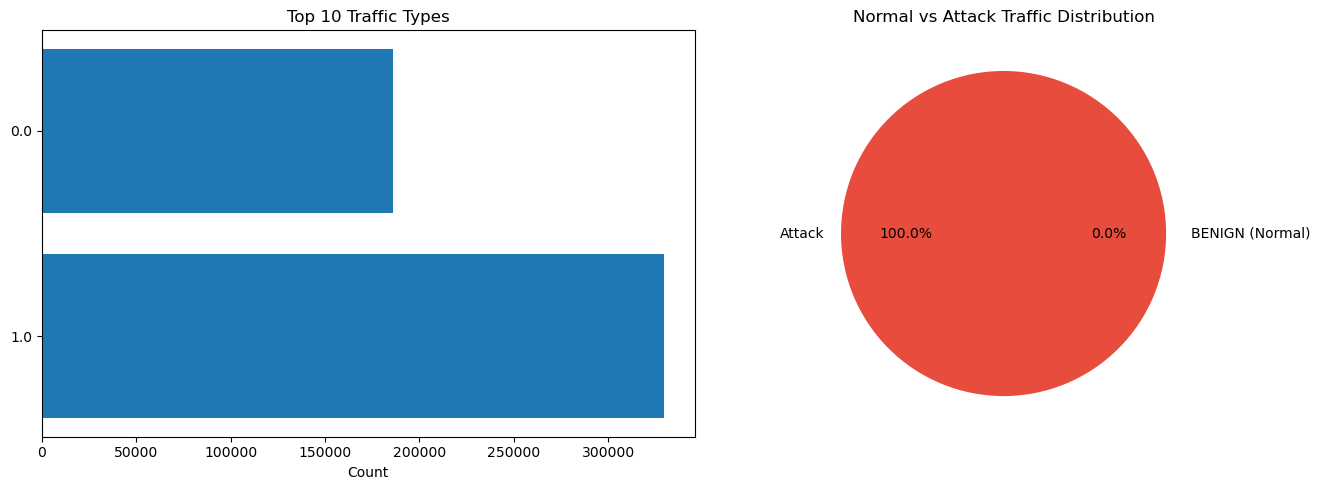


✅ Label distribution plot saved as 'label_distribution.png'


In [7]:
if df_full is not None:
    print("\n2. Label Analysis...")
    print("-" * 40)
    
    # Find Label column
    label_col = None
    for col in df_full.columns:
        if col.lower() == 'label':
            label_col = col
            break
    
    if label_col:
        print(f"Label column found: '{label_col}'")
        
        # Check for BENIGN class
        print(f"\nUnique labels: {df_full[label_col].nunique()}")
        
        # Get label distribution
        label_counts = df_full[label_col].value_counts()
        print(f"\nLabel distribution (top 15):")
        for label, count in label_counts.head(15).items():
            pct = (count / len(df_full)) * 100
            print(f"  {label}: {count:,} ({pct:.2f}%)")
        
        # Calculate BENIGN vs Attack
        benign_mask = df_full[label_col].astype(str).str.upper() == 'BENIGN'
        benign_count = benign_mask.sum()
        attack_count = len(df_full) - benign_count
        
        print(f"\n{'='*40}")
        print(f"BENIGN (Normal) samples: {benign_count:,} ({benign_count/len(df_full)*100:.2f}%)")
        print(f"Attack samples: {attack_count:,} ({attack_count/len(df_full)*100:.2f}%)")
        print(f"{'='*40}")
        
        # Plot distribution
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Top 10 labels
        top_labels = label_counts.head(10)
        axes[0].barh(range(len(top_labels)), top_labels.values)
        axes[0].set_yticks(range(len(top_labels)))
        axes[0].set_yticklabels(top_labels.index)
        axes[0].set_xlabel('Count')
        axes[0].set_title('Top 10 Traffic Types')
        
        # BENIGN vs Attack pie chart
        axes[1].pie([benign_count, attack_count], 
                    labels=['BENIGN (Normal)', 'Attack'], 
                    autopct='%1.1f%%',
                    colors=['#2ecc71', '#e74c3c'],
                    explode=(0.05, 0))
        axes[1].set_title('Normal vs Attack Traffic Distribution')
        
        plt.tight_layout()
        plt.savefig('label_distribution.png', dpi=100, bbox_inches='tight')
        plt.show()
        
        print("\n✅ Label distribution plot saved as 'label_distribution.png'")
    else:
        print("ERROR: No 'Label' column found in dataset")
        print(f"Available columns: {df_full.columns[:10].tolist()}")

### note :
isolation forest is an unsupervised algorithm and shouldn't see labels during training

### Data quality assessement 

In [8]:
if df_full is not None:
    print("\n3. Data Quality Assessment...")
    print("-" * 40)
    
    # Drop label column for feature analysis
    label_col = None
    for col in df_full.columns:
        if col.strip().lower() == 'label':
            label_col = col
            break
    
    if label_col:
        X = df_full.drop(columns=[label_col])
        y = df_full[label_col]
    else:
        X = df_full
        y = None
    
    # Check for missing values
    print("\n3.1 Missing Values Analysis:")
    missing_counts = X.isnull().sum()
    missing_cols = missing_counts[missing_counts > 0]
    
    if len(missing_cols) > 0:
        print(f"  Columns with missing values: {len(missing_cols)}")
        missing_pct = (missing_cols / len(X)) * 100
        print(f"  Top 10 columns by missing percentage:")
        for col, pct in missing_pct.sort_values(ascending=False).head(10).items():
            print(f"    {col}: {pct:.2f}%")
    else:
        print("  ✅ No missing values found!")
    
    # Check for infinite values
    print("\n3.2 Infinite Values Analysis:")
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    inf_count_total = 0
    inf_cols_list = []
    
    for col in numeric_cols:
        inf_count = (X[col].isin([np.inf, -np.inf])).sum()
        if inf_count > 0:
            inf_count_total += inf_count
            inf_cols_list.append(col)
    
    if inf_count_total > 0:
        print(f"  Columns with infinite values: {len(inf_cols_list)}")
        print(f"  Total infinite values: {inf_count_total:,}")
        print(f"  First 5 columns: {inf_cols_list[:5]}")
    else:
        print("  ✅ No infinite values found!")
    
    # Check data types
    print("\n3.3 Data Types:")
    numeric_count = len(X.select_dtypes(include=[np.number]).columns)
    object_count = len(X.select_dtypes(include=['object']).columns)
    print(f"  Numeric columns: {numeric_count}")
    print(f"  Object columns: {object_count}")
    
    # Check memory usage
    memory_mb = X.memory_usage(deep=True).sum() / 1024**2
    print(f"\n3.4 Memory Usage: {memory_mb:.2f} MB")


3. Data Quality Assessment...
----------------------------------------

3.1 Missing Values Analysis:
  Columns with missing values: 186
  Top 10 columns by missing percentage:
    Attack subcategory: 99.99%
    Attack category: 99.99%
    Number of events: 99.99%
    Unnamed: 38: 99.39%
    Unnamed: 37: 97.24%
    ct_ftp_cmd: 90.79%
    ct_src_ltm: 90.79%
    is_ftp_login: 90.79%
    ct_src_dport_ltm: 90.79%
    ct_dst_sport_ltm: 90.79%

3.2 Infinite Values Analysis:


KeyboardInterrupt: 

### Feature Statistics :

In [ ]:
if df_full is not None:
    print("\n4. Feature Statistics...")
    print("-" * 40)
    
    # Get numeric columns
    if label_col:
        X = df_full.drop(columns=[label_col])
    else:
        X = df_full
    
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    print(f"Total numeric features: {len(numeric_cols)}")
    
    # Basic statistics
    print("\nStatistics for first 10 numeric features:")
    print(X[numeric_cols[:10]].describe())
    
    # Check for constant features
    constant_cols = []
    for col in numeric_cols:
        if X[col].nunique() <= 1:
            constant_cols.append(col)
    
    if constant_cols:
        print(f"\nConstant features (zero variance): {len(constant_cols)}")
        print(f"First 10: {constant_cols[:10]}")
        print("These will be removed during preprocessing")
    else:
        print("\n✅ No constant features found")


4. Feature Statistics...
----------------------------------------
Total numeric features: 78

Statistics for first 10 numeric features:
        Destination Port   Flow Duration   Total Fwd Packets  \
count        5661486.000     5661486.000         5661486.000   
mean            8071.483    14785663.930               9.361   
std            18283.631    33653741.114             749.673   
min                0.000         -13.000               1.000   
25%               53.000         155.000               2.000   
50%               80.000       31316.000               2.000   
75%              443.000     3204858.250               5.000   
max            65535.000   119999998.000          219759.000   

        Total Backward Packets  Total Length of Fwd Packets  \
count              5661486.000                  5661486.000   
mean                    10.394                      549.302   
std                    997.388                     9993.588   
min                      0.000    

In [ ]:
if df_full is not None:
    print("\n5. Sampling Recommendation...")
    print("-" * 40)
    
    total_rows = len(df_full)
    print(f"Total dataset size: {total_rows:,} rows")
    
    if total_rows > 500000:
        print(f"\n⚠️  Dataset is large ({total_rows:,} rows)")
        print("Recommendation: Use sampling for training")
        print(f"  - Sample size: 200,000 - 500,000 rows")
        print("  - This will significantly speed up training")
        print("  - Isolation Forest works well with sampled data")
    else:
        print("\n✅ Dataset size is manageable")
        print("  - Can use full dataset for training")


5. Sampling Recommendation...
----------------------------------------
Total dataset size: 5,661,486 rows

⚠️  Dataset is large (5,661,486 rows)
Recommendation: Use sampling for training
  - Sample size: 200,000 - 500,000 rows
  - This will significantly speed up training
  - Isolation Forest works well with sampled data


In [ ]:
print("\n6. Preprocessing Plan...")
print("-" * 40)
print("Based on exploration, the preprocessing will:")
print("1. Load all CSV files from data/raw/")
print("2. Remove label column BEFORE training (unsupervised)")
print("3. Handle missing values (drop columns with >50% missing)")
print("4. Replace infinite values with 0")
print("5. Keep only numeric columns")
print("6. Remove constant/zero-variance columns")
print("7. Apply StandardScaler normalization")
print("8. Save processed data for training")


6. Preprocessing Plan...
----------------------------------------
Based on exploration, the preprocessing will:
1. Load all CSV files from data/raw/
2. Remove label column BEFORE training (unsupervised)
3. Handle missing values (drop columns with >50% missing)
4. Replace infinite values with 0
5. Keep only numeric columns
6. Remove constant/zero-variance columns
7. Apply StandardScaler normalization
8. Save processed data for training
